# Week 14 KMeans and Dimensionality Reduction
When you don't have a target variable and want to predict groupings of values, K-Means is the machine learning algorithm to use.  In the Machine Learning process, there are often many columns. To reduce the number of columns used to make predictions, you will learn to reduce the number of columns to the most important  or a combination of columns.  The dimensionality reduction method we will use is Principal Component Analysis (PCA).

In [136]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer, load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import silhouette_score

# Load Dataset from Sci-Kit Learn library


In [137]:
# Load Breast Cancer dataset
data = load_wine(as_frame = True)
X = data.data
y = data.target # Ground truth for comparison later

# Display the data structure

In [138]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
dtypes: fl

## PCA Explained 

---

## Start With a Simple Idea

Imagine you're describing your classmates and you measure **20 things** about each person:
- Height, weight, shoe size, arm length, leg length...

You'd quickly notice that **tall people also tend to have bigger shoes, longer arms, longer legs**. These measurements are kind of saying the **same thing** — "this person is big."

PCA says: **why use 20 numbers when 1 or 2 can tell most of the story?**

---

## The Shadow Analogy

Imagine a **3D sculpture** and you shine a light on it to cast a **shadow on the wall**.

- The sculpture = your high-dimensional data
- The shadow = PCA's reduced version

PCA finds the **best angle to shine the light** so the shadow **preserves as much shape/detail as possible**. You go from 3D → 2D but still recognize what it is.

---

## What PCA Actually Does

| Step | What's Happening |
|---|---|
| 1 | Looks at all your features together |
| 2 | Finds which **combinations** of features capture the most variation |
| 3 | Ranks them — **PC1 captures the most**, PC2 next, etc. |
| 4 | You keep only the **top few** and drop the rest |

The new features (called **principal components**) aren't original measurements anymore — they're **mixes** of the originals.

---

## A Concrete Example

Say you have **3 features** for each student:

```
Hours Studied, Practice Test Score, Final Exam Score
```

These are all related — students who study more tend to score higher on both tests. PCA might combine all three into **1 new feature** that basically means:

```
PC1 ≈ "Overall Academic Performance"
```

You went from **3 columns → 1 column** and kept most of the information.

---

## Why Do We Use It?

- Too many features **confuses** machine learning models — like trying to listen to 20 people talk at once
- PCA **reduces the noise** and keeps the important patterns
- It also helps you **visualize** data — you can't plot 20 dimensions, but you can plot 2

---

## The One Catch

The new PCA features are **harder to interpret** — PC1 doesn't mean anything you can point to like "height" or "score." It's a mathematical mix. That's the tradeoff — **simplicity in exchange for explainability**.

# Q1 - K-Means Pipeline & Grid Search
Find the optimal number of clusters (k).
- Create a pipeline called kmeans_pipeline that
- SimpleImputer called 'imputer' strategy = 'mean'
- StandardScaler() called 'scaler'
- PCA() called 'pca' 
- Create a KMeans(random_state = 42, n_init = 10 called 'kmeans'

In [139]:
kmeans_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy = 'mean')), 
    ('scaler', StandardScaler()),
    ('pca', PCA()),
    ('kmeans', KMeans(random_state = 42, n_init = 10))])
    

# Q2 - Grid search focusing on Clusters and dimensions
- create a dictionary called kmeans_param_grid = {
- set the 'pca__n_components' to [2, 3, 4, 5, 10],
- set the 'kmeans__n_clusters' to [2, 3, 4, 5]


In [140]:
kmeans_param_grid = {
    'pca__n_components' : [2, 3, 4, 5, 10],
    'kmeans__n_clusters' : [2, 3, 4, 5]}

## Silhouette Score Explained 

---

## Start With a Simple Idea

Imagine it's the first day at a new school and everyone is clustering into friend groups at lunch:

- The **Gamers** table
- The **Athletes** table
- The **Art Kids** table

A good seating arrangement means:
- People at the **same table** have a lot in common ✓
- People at **different tables** have little in common ✓

The Silhouette Score is just a way to **measure how good the grouping is** using those exact two ideas.

---

## The Two Questions It Asks

For **every single person** in the data, it asks:

### Question 1 — How well do you fit WITH your own group?
```
How similar are you to the people at YOUR table?

Small distance = you really belong here ✓
Large distance = you feel out of place ✗
```

### Question 2 — How far are you FROM the nearest other group?
```
How different are you from the CLOSEST other table?

Large distance = you clearly don't belong there ✓
Small distance = you could have gone either way ✗
```

---

## The Score Formula

```
Silhouette Score = (Distance Away From Others - Distance Within Group)
                   ─────────────────────────────────────────────────
                          Max of those two distances
```

Don't stress the math — just know it spits out a number between **-1 and +1**

---

## What the Number Means

```
   -1          0          +1
    |──────────|──────────|
    ✗✗✗      meh        ✓✓✓

```

| Score | Meaning | Lunch Table Translation |
|---|---|---|
| Close to +1 | Great clustering | Everyone at the right table, clear separation |
| Around 0 | Meh clustering | Some kids could go to either table |
| Close to -1 | Bad clustering | Kids are at the WRONG table |

---

## A Visual Example

Imagine plotting students by **how much they like video games vs sports**:

```
How much                                
they like    ★ ★                    ● ●
video    ★ ★ ★                   ● ● ●
games        ★ ★                    ● ●

            Gamers                Athletes
            group                  group
        ──────────────────────────────────►
                    How much they like sports
```

**Good clustering** — stars are tight together, circles are tight together, and the two groups are far apart → **Score close to +1** ✓

---

```
How much                                
they like    ★ ● ★                  ● ★
video    ★ ● ★ ●                 ● ★ ●
games        ● ★ ●                  ★ ●

            Mixed up!!              Mixed up!!
        ──────────────────────────────────►
                    How much they like sports
```

**Bad clustering** — stars and circles all mixed together → **Score close to 0 or -1** ✗

---

## How It Connects to KMeans and Grid Search

Remember Grid Search was trying every combo of hyperparameters looking for the **best score**?

```
n_clusters = 2  →  Silhouette Score = 0.31
n_clusters = 3  →  Silhouette Score = 0.58  ← Grid Search picks this ✓
n_clusters = 4  →  Silhouette Score = 0.41
n_clusters = 5  →  Silhouette Score = 0.29
```

The Silhouette Score is the **judge** that tells Grid Search which number of clusters made the cleanest, most separated groups — just like judging which lunch seating arrangement made the most natural friend groups.

# Q3 -Metric: Silhouette Score
- Define a function called kmeans_scorer with parameter est and X.
- assign est.fit_predict(X) to the variable labels
- return silhouette_score(X, labels)

In [141]:
def kmeans_scorer(est, X):
   # Transform X through all steps EXCEPT the final KMeans
    X_transformed = est[:-1].transform(X)  # Imputer → Scaler → PCA output
    labels = est.fit_predict(X)             # full pipeline for labels   
    if len(np.unique(labels)) < 2:
        return -1    
    return silhouette_score(X_transformed, labels)  # consistent space ✓

## Grid Search CV Explained Like You're in 9th Grade

---

## Start With a Simple Idea

Imagine you're making the **perfect bowl of ramen** and you have a few decisions to make:

- Broth temperature: **Low, Medium, High**
- Cook time: **3 min, 5 min, 7 min**
- Salt amount: **A little, Medium, A lot**

How do you find the **best combination?** You could guess... or you could **try every single combination** and see which one tastes best.

**That's exactly what Grid Search does.**

---

## The "Grid" Part

Every combination laid out in a table looks like a **grid**:

| | 3 min | 5 min | 7 min |
|---|---|---|---|
| **Low Heat** | 🍜 | 🍜 | 🍜 |
| **Medium Heat** | 🍜 | 🍜 | 🍜 |
| **High Heat** | 🍜 | 🍜 | 🍜 |

Grid Search **systematically tries every cell** in this grid — no guessing, no skipping.

In machine learning the "ingredients" are called **hyperparameters** — like how many clusters KMeans should make, or how many components PCA should keep.

---

## The "CV" Part — Cross Validation

CV stands for **Cross Validation** and it answers the question:

> *"How do I know if a combination is actually good, or just got lucky?"*

Here's how it works with a deck of cards analogy:

```
Your Data = a deck of 50 cards

Split into 5 groups (called "folds"):
┌──────────┬──────────┬──────────┬──────────┬──────────┐
│  Fold 1  │  Fold 2  │  Fold 3  │  Fold 4  │  Fold 5  │
│ 10 cards │ 10 cards │ 10 cards │ 10 cards │ 10 cards │
└──────────┴──────────┴──────────┴──────────┴──────────┘
```

For **each combination of settings**, it does this 5 times:

```
Round 1: Train on Folds 2,3,4,5 → Test on Fold 1 → Score it
Round 2: Train on Folds 1,3,4,5 → Test on Fold 2 → Score it
Round 3: Train on Folds 1,2,4,5 → Test on Fold 3 → Score it
Round 4: Train on Folds 1,2,3,5 → Test on Fold 4 → Score it
Round 5: Train on Folds 1,2,3,4 → Test on Fold 5 → Score it

Final Score = Average of all 5 rounds
```

Averaging across folds means **one lucky result can't fool you.**

---

## Putting It Together

```
For EVERY combination of hyperparameters:
    Run Cross Validation (5 rounds)
    Average the scores
    
Pick the combination with the BEST average score ✓
```

---

## A Real ML Example

```python
param_grid = {
    'pca__n_components': [2, 3, 4],    # 3 choices
    'kmeans__n_clusters': [3, 4, 5, 6] # 4 choices
}
```

| | n_clusters=3 | n_clusters=4 | n_clusters=5 | n_clusters=6 |
|---|---|---|---|---|
| **n_components=2** | test it | test it | test it | test it |
| **n_components=3** | test it | test it | test it | test it |
| **n_components=4** | test it | test it | test it | test it |

That's **12 combinations × 5 folds = 60 total training runs** just to find the best settings — Grid Search does all 60 **automatically.**

---

## The One Catch

If your grid is huge with many hyperparameters and many values, Grid Search can get **very slow** — like trying every possible ramen recipe in the universe. That's why you have to be smart about how big your grid is.

---

## Bottom Line

| Term | Plain English |
|---|---|
| **Grid** | Every possible combination of settings |
| **Search** | Try all of them and score each one |
| **CV** | Test each combo multiple times to get a fair score |
| **Best Params** | The winning combination 🏆 |

# Q4 - Grid search for the best KMeans Model
- assign GridSearchCV with parameters kmeans_pipeline to a variable kmeans_grid 
- param_grid = kmeans_param_grid,
- scoring = kmeans_scorer)
- fit km_grid on X (features)
- print the f"Best K-Means Params: {kmeans_grid.best_params_}")


In [142]:
kmeans_grid = GridSearchCV(kmeans_pipeline, 
                param_grid = kmeans_param_grid,
                scoring = kmeans_scorer,
                cv = 5,
                refit = True)
kmeans_grid.fit(X)

print(f'Best K-Means Params: {kmeans_grid.best_params_}')

Best K-Means Params: {'kmeans__n_clusters': 2, 'pca__n_components': 2}


# Q5 Create a KMeans model with the best parameters
- assign kmeans_grid.best_estimator_ to best_kmeans
- assign the best_km.named_steps['kmeans'].labels_  to kmeans_labels (Theses are the predictions)
- print out f"K-means Silhouette Score: {km_grid.best_score_: .4f"

In [143]:
best_kmeans = kmeans_grid.best_estimator_
kmeans_labels = best_kmeans.named_steps['kmeans'].labels_
print(f"K-Means Silhouette Score: {kmeans_grid.best_score_: .4f}")

K-Means Silhouette Score:  0.3951


# Q6 - How is the Silhouette interpreted?
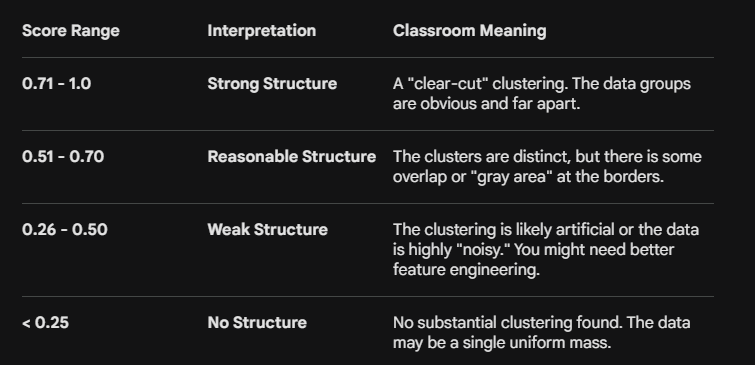

# How is the silhouette score interpreted?
- Assign "Strong Structure" to A1
- Assign "Reasonable Structure" to A2
- Assign "Weak Structure" to A3
- Assign "No Structure" to A4
- Assign the interpretation to the variable score

In [144]:
A1 = "Strong Structure"
A2 = "Reasonable Structure"
A3 = "Weak Structure"
A4 = "No Structure"
score = A3

# Elbow Method
Think of the **Elbow Method** like trying to decide how many bins you need to organize a messy pile of LEGOs.

### The Big Idea
In K-Means clustering, we have to tell the computer how many groups (or "clusters") to make. But the computer doesn't know the "right" answer. If you have 100 LEGOs, you *could* put them into 100 tiny bins, but that doesn't really help you stay organized. On the other hand, putting them all in 1 bin doesn't help you find the pieces you need. 

The **Elbow Method** helps us find the "Sweet Spot"—the perfect number of groups.

---

### How it Works (The "Tightness" Test)
The computer runs a test for different numbers of clusters (like 1, 2, 3, 4, and 5). For each number, it calculates something called **Inertia**. 

* **Inertia** is just a fancy word for how much "empty space" is inside your clusters. 
* If your clusters are very tight and the points are close together, the Inertia score is **low**.
* If your clusters are huge and messy, the Inertia score is **high**.



---

### The Graph
We plot these scores on a line graph.
1.  When we move from **1 cluster** to **2**, the Inertia usually drops a huge amount because the data is much more organized.
2.  As we add more clusters, the line keeps going down, but it starts to slow down.
3.  Eventually, the line looks like a human arm bent at the elbow.



---

### Why we call it the "Elbow"
The goal is to find the **"Elbow Point."** * **Before the Elbow:** Adding more clusters helps a lot. It’s like going from one giant box of LEGOs to sorting them by color—it makes a big difference!
* **After the Elbow:** Adding more clusters doesn't help much anymore. It's like sorting your red LEGOs by "Red," "Slightly Darker Red," and "Bright Red." It’s overkill and just makes things more complicated.

**The Lesson:** When you see that "bend" in the arm on your graph, that is the number of clusters you should pick! It’s the point where you get the most organization without making things too complicated.


# Q7 - Preparing Data for Elbow Method Chart
- create an empty list called inertias_values
- assign range(2, 11) to kmeans
- create a for loop with k as the index through kmeans
- assign KMeans(n_clusters = k, random_state = 42) to kms
- fit kms using X features
- append the kms.inertia_ to inertias_values list

In [145]:
inertias_values = []
kmeans = range(2, 11)

for k in kmeans:
    kms = KMeans(n_clusters = k, random_state = 42)
    X_pca = kmeans_pipeline[ : -1].fit_transform(X)
    # X_pca = X
    kms.fit(X_pca)
    inertias_values.append(kms.inertia_)

# Q8 - Elbow Method Chart output
- create plt.figure with figsize = (6, 6)
- create plt.plot with parameters kms, inertias, marker = "o"
- create plt.title as "Elbow Method for Choosing the k the number of clusters"
- create plt.xlabel as "Number of Clusters (k)"
- create plt.ylabel as "Inertia"
- create plt.show()

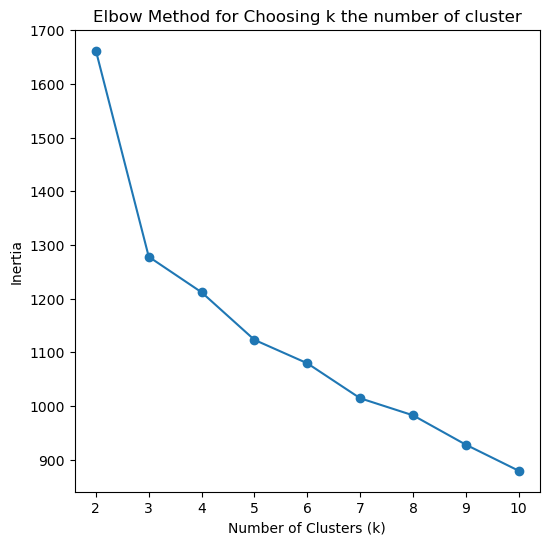

In [146]:
plt.figure(figsize  =(6, 6))
plt.plot(kmeans, inertias_values, marker = "o")
plt.title("Elbow Method for Choosing k the number of cluster")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.show()


Looking at your plot, this is what we call a **"lazy elbow."** It isn't a sharp, 90-degree break, which suggests the clusters in your data might be somewhat overlapping or that the data is naturally more continuous.

### The Data Scientist's Diagnosis

In a plot like this, I look for the point of **maximum curvature**—where the "gain" in tightening clusters starts to diminish significantly compared to the "cost" of adding more clusters.

1.  **The "Structural" Elbow ($k=3$):** This is the most defensible choice from a mathematical standpoint. The drop from $k=2$ to $k=3$ is massive. After $k=3$, the line's "slope" changes noticeably. If you want a model that is simple and likely to generalize well, $k=3$ is your winner.
2.  **The "Granular" Elbow ($k=5$):** Notice how the line segment between $4$ and $5$ is steeper than the segment between $5$ and $6$. There is a tiny "kink" at $k=5$. If your business goal requires more specific targeting or segments, $k=5$ is the absolute maximum I would consider before the gains become negligible.

---

### Why we need your Silhouette Score
Because this elbow is ambiguous, the **Silhouette Score** you are calculating in your GridSearch is the "tie-breaker."

* **If Silhouette is highest at $k=3$:** The data naturally forms three distinct groups.
* **If Silhouette is highest at $k=5$:** The data has sub-structures that are worth keeping, even if the inertia doesn't drop as much.



### My Professional Recommendation
1.  **Focus on $k=3$.** Most real-world datasets with this type of curve perform best at the first major bend.
2.  **Check the cluster sizes.** If you pick $k=5$ and one cluster only has 2% of your data, the model is likely over-fitting to outliers, and you should revert to $k=3$.
3.  **Cross-validate.** Since you are using `GridSearchCV`, look at the **mean_test_score** (your silhouette score) across the folds. If $k=3$ has a lower standard deviation (more stable) than $k=5$, it’s the safer bet.

Between $k=3$ and $k=5$, which one is your `GridSearchCV` currently leaning towards?

# Q9 Which cluster is at the Elbow?
- Assign the number of clusters at the elbow to the variable ANS.
- Convert the list to an array and assign it to ie
- display ie
- In a new code cell, assign the value in ie that is associated with the number of clusters.

In [147]:
# since the best number of clusters is 2 we will use 3
ANS = 3
ie = np.array(inertias_values)
ie

array([1661.67611656, 1277.92848884, 1211.75311347, 1123.15654708,
       1079.53850916, 1014.43090869,  982.65497629,  927.95607607,
        879.42570075])

In [148]:
inertia_value = 1277.92848884